In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sympy as sym

print("All libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {sp.__version__}")
print(f"SymPy version: {sym.__version__}")

All libraries loaded successfully!
NumPy version: 2.4.4
SciPy version: 1.17.1
SymPy version: 1.14.0


In [4]:
# BLACK HOLE & WHITE HOLE SIMULATION PARAMETERS
# ============================================

# Fundamental Constants
G = 6.674e-11        # Gravitational constant (m^3 kg^-1 s^-2)
c = 3e8              # Speed of light (m/s)
hbar = 1.055e-34     # Reduced Planck constant (for Hawking radiation)

# Black Hole Properties
M = 1.989e30         # Mass of black hole (kg) — set to 1 solar mass
rs = (2 * G * M) / c**2   # Schwarzschild radius (event horizon)

# White Hole Properties (mirror of black hole)
M_white = M          # Same mass as black hole
rs_white = rs        # Same Schwarzschild radius

# Simulation Grid
r_min = rs * 1.01    # Just outside event horizon
r_max = rs * 100     # Far field boundary
num_points = 1000    # Resolution of simulation

# Time Parameters
t_start = 0          # Start time (seconds)
t_end = 1000         # End time (seconds)
dt = 0.1             # Time step (seconds)

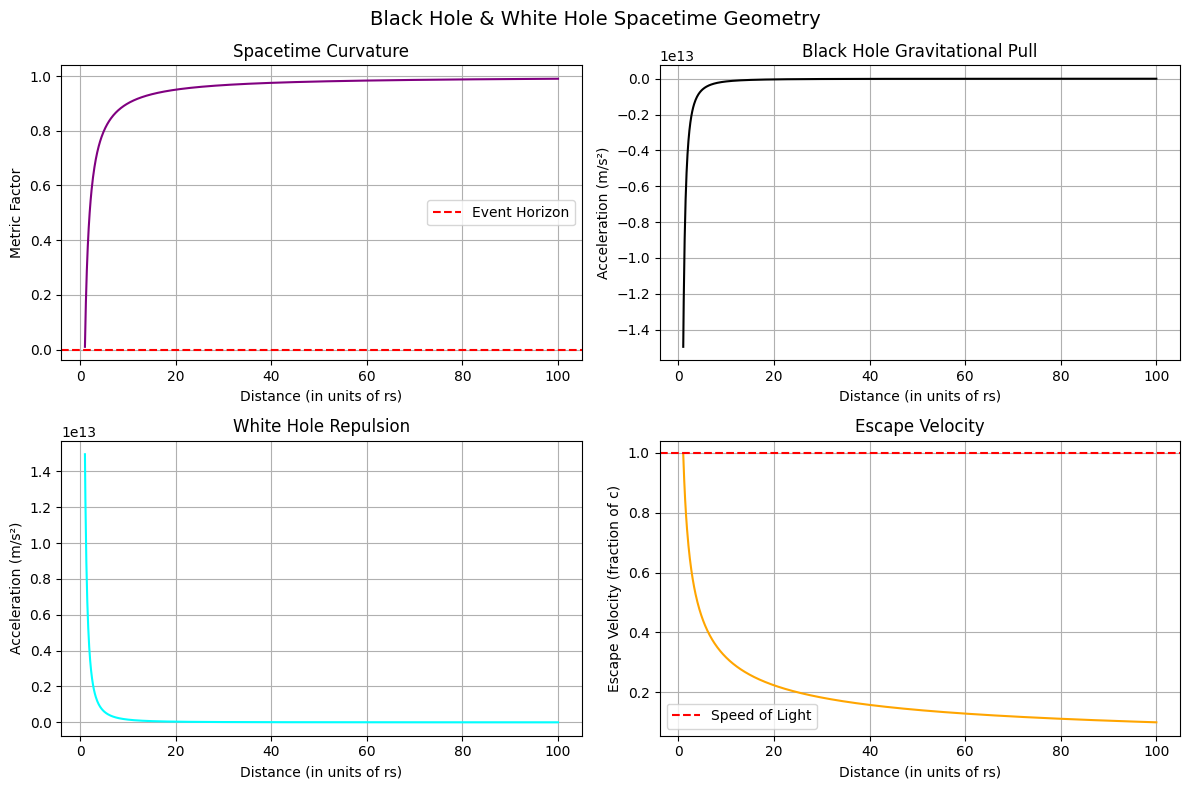

At event horizon, escape velocity = 1.00c
Metric factor at event horizon = 0.0010
Black hole pulls at -1.525e+13 m/s² at event horizon


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# SPACETIME GEOMETRY & GRAVITY
# ============================================

def schwarzschild_metric(r, M):
    """
    Describes how spacetime is curved around the black hole.
    Returns 0 at event horizon, negative inside — time and space swap!
    """
    rs = (2 * G * M) / c**2
    factor = 1 - (rs / r)
    return factor

def gravitational_acceleration(r, M):
    """
    Gravitational pull at distance r from black hole.
    Negative means pulling inward toward singularity.
    """
    rs = (2 * G * M) / c**2
    a = -(G * M) / r**2
    return a

def white_hole_acceleration(r, M):
    """
    White hole is time-reversed black hole.
    Positive means pushing outward — nothing can enter.
    """
    return -gravitational_acceleration(r, M)

def escape_velocity(r, M):
    """
    Speed needed to escape gravitational pull at distance r.
    At event horizon this equals the speed of light!
    """
    v_esc = np.sqrt((2 * G * M) / r)
    return v_esc

# ============================================
# COMPUTE ACROSS SPACE
# ============================================

# Create range of distances from just outside event horizon
r_values = np.linspace(r_min, r_max, num_points)

# Calculate everything across all distances
metric_values = schwarzschild_metric(r_values, M)
gravity_values = gravitational_acceleration(r_values, M)
white_hole_values = white_hole_acceleration(r_values, M)
escape_values = escape_velocity(r_values, M)

# ============================================
# VISUALIZE GRAVITY
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Black Hole & White Hole Spacetime Geometry", fontsize=14)

# Plot 1 - Schwarzschild Metric
axes[0,0].plot(r_values/rs, metric_values, color='purple')
axes[0,0].axhline(y=0, color='red', linestyle='--', label='Event Horizon')
axes[0,0].set_title("Spacetime Curvature")
axes[0,0].set_xlabel("Distance (in units of rs)")
axes[0,0].set_ylabel("Metric Factor")
axes[0,0].legend()
axes[0,0].grid(True)

# Plot 2 - Black Hole Gravity
axes[0,1].plot(r_values/rs, gravity_values, color='black')
axes[0,1].set_title("Black Hole Gravitational Pull")
axes[0,1].set_xlabel("Distance (in units of rs)")
axes[0,1].set_ylabel("Acceleration (m/s²)")
axes[0,1].grid(True)

# Plot 3 - White Hole Gravity
axes[1,0].plot(r_values/rs, white_hole_values, color='cyan')
axes[1,0].set_title("White Hole Repulsion")
axes[1,0].set_xlabel("Distance (in units of rs)")
axes[1,0].set_ylabel("Acceleration (m/s²)")
axes[1,0].grid(True)

# Plot 4 - Escape Velocity
axes[1,1].plot(r_values/rs, escape_values/c, color='orange')
axes[1,1].axhline(y=1, color='red', linestyle='--', label='Speed of Light')
axes[1,1].set_title("Escape Velocity")
axes[1,1].set_xlabel("Distance (in units of rs)")
axes[1,1].set_ylabel("Escape Velocity (fraction of c)")
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

print(f"At event horizon, escape velocity = {escape_velocity(rs, M)/c:.2f}c")
print(f"Metric factor at event horizon = {schwarzschild_metric(rs*1.001, M):.4f}")
print(f"Black hole pulls at {gravitational_acceleration(rs, M):.3e} m/s² at event horizon")

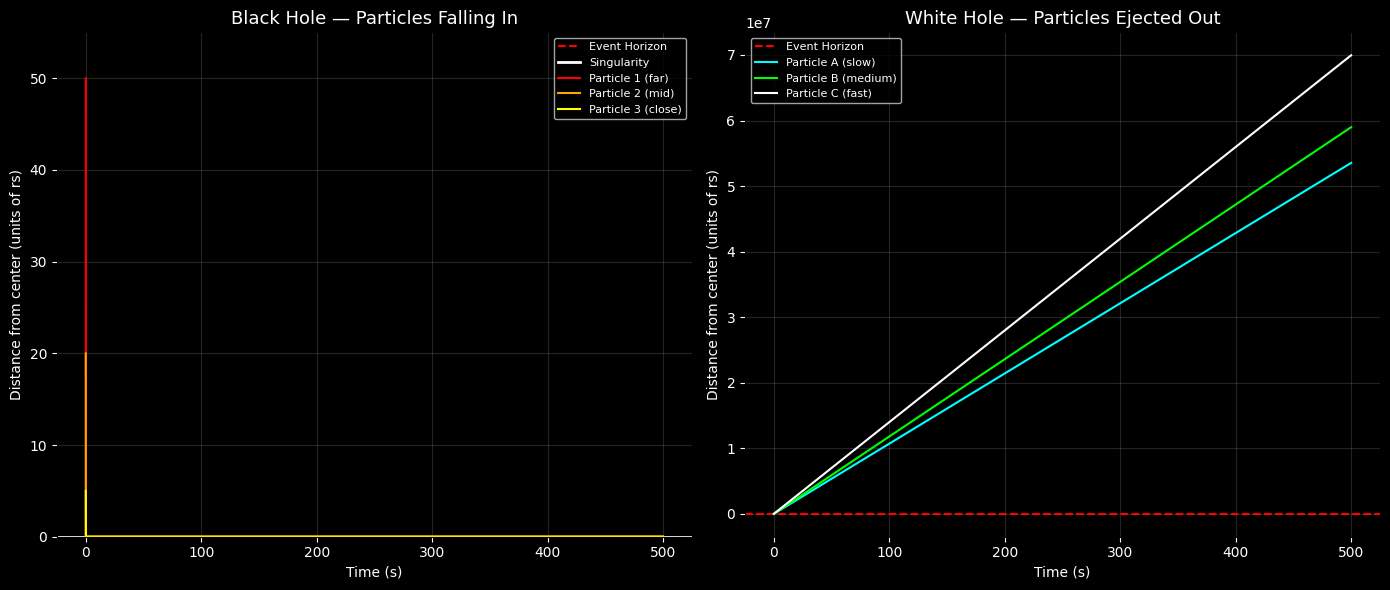

Simulation complete!
Black hole particles simulated: 3
White hole particles simulated: 3


In [13]:
# ============================================
# PARTICLE SIMULATION
# ============================================

from scipy.integrate import solve_ivp

def equations_of_motion(t, state, M, hole_type='black'):
    """
    Describes how a particle moves in curved spacetime.
    state = [position, velocity]
    hole_type = 'black' (attracts) or 'white' (repels)
    """
    r, v = state
    
    # Prevent particle from hitting singularity
    if r <= rs * 0.01:
        return [0, 0]
    
    # Choose black hole or white hole behavior
    if hole_type == 'black':
        a = gravitational_acceleration(r, M)
    else:
        a = white_hole_acceleration(r, M)
    
    # Relativistic correction — gravity strengthens near horizon
    metric = abs(schwarzschild_metric(r, M))
    if metric > 0:
        a = a / metric
        
    return [v, a]

# ============================================
# INITIAL CONDITIONS
# ============================================

# Black hole particles — falling inward from different distances
black_hole_particles = [
    {"r0": rs * 50,  "v0": 0,      "color": "red",    "label": "Particle 1 (far)"},
    {"r0": rs * 20,  "v0": 0,      "color": "orange",  "label": "Particle 2 (mid)"},
    {"r0": rs * 5,   "v0": 0,      "color": "yellow",  "label": "Particle 3 (close)"},
]

# White hole particles — being ejected outward from different distances
white_hole_particles = [
    {"r0": rs * 1.5, "v0": c * 0.1, "color": "cyan",   "label": "Particle A (slow)"},
    {"r0": rs * 1.5, "v0": c * 0.5, "color": "lime",   "label": "Particle B (medium)"},
    {"r0": rs * 1.5, "v0": c * 0.9, "color": "white",  "label": "Particle C (fast)"},
]

# Time range for simulation
t_span = (0, 500)
t_eval = np.linspace(0, 500, 5000)

# ============================================
# RUN THE SIMULATION
# ============================================

bh_results = []
wh_results = []

# Simulate black hole particles
for p in black_hole_particles:
    sol = solve_ivp(
        equations_of_motion,
        t_span,
        [p["r0"], p["v0"]],
        args=(M, 'black'),
        t_eval=t_eval,
        max_step=0.1,
        method='RK45'
    )
    bh_results.append(sol)

# Simulate white hole particles    
for p in white_hole_particles:
    sol = solve_ivp(
        equations_of_motion,
        t_span,
        [p["r0"], p["v0"]],
        args=(M, 'white'),
        t_eval=t_eval,
        max_step=0.1,
        method='RK45'
    )
    wh_results.append(sol)

# ============================================
# VISUALIZE PARTICLES
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('black')

# --- Black Hole Plot ---
axes[0].set_facecolor('black')
axes[0].set_title("Black Hole — Particles Falling In", color='white', fontsize=13)

# Draw event horizon
axes[0].axhline(y=rs, color='red', linestyle='--', linewidth=1.5, label='Event Horizon')

# Draw singularity
axes[0].axhline(y=0, color='white', linestyle='-', linewidth=2, label='Singularity')

for i, (p, sol) in enumerate(zip(black_hole_particles, bh_results)):
    axes[0].plot(sol.t, sol.y[0]/rs, color=p["color"], label=p["label"], linewidth=1.5)

axes[0].set_xlabel("Time (s)", color='white')
axes[0].set_ylabel("Distance from center (units of rs)", color='white')
axes[0].tick_params(colors='white')
axes[0].legend(facecolor='black', labelcolor='white', fontsize=8)
axes[0].set_ylim(0, 55)
axes[0].grid(True, alpha=0.2)

# --- White Hole Plot ---
axes[1].set_facecolor('black')
axes[1].set_title("White Hole — Particles Ejected Out", color='white', fontsize=13)

# Draw event horizon
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Event Horizon')

for i, (p, sol) in enumerate(zip(white_hole_particles, wh_results)):
    axes[1].plot(sol.t, sol.y[0]/rs, color=p["color"], label=p["label"], linewidth=1.5)

axes[1].set_xlabel("Time (s)", color='white')
axes[1].set_ylabel("Distance from center (units of rs)", color='white')
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='black', labelcolor='white', fontsize=8)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("Simulation complete!")
print(f"Black hole particles simulated: {len(bh_results)}")
print(f"White hole particles simulated: {len(wh_results)}")

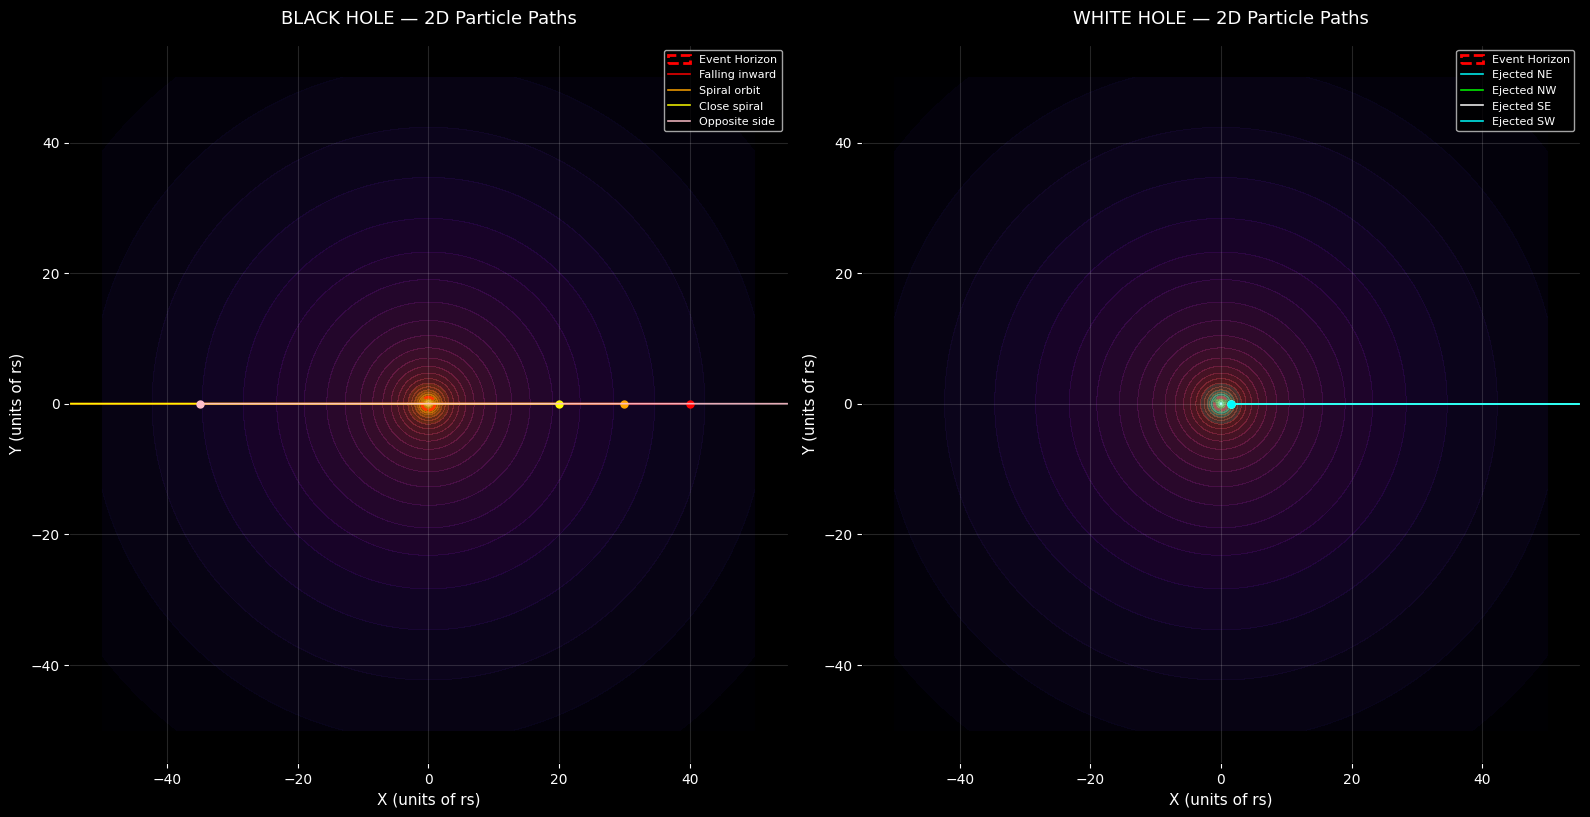

2D Simulation complete!


In [14]:
# ============================================
# 2D SPATIAL VISUALIZATION
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Circle
from matplotlib.colors import LogNorm

# ============================================
# BUILD 2D GRAVITY FIELD
# ============================================

# Create 2D grid
grid_size = 300
x = np.linspace(-50 * rs, 50 * rs, grid_size)
y = np.linspace(-50 * rs, 50 * rs, grid_size)
X, Y = np.meshgrid(x, y)

# Distance from center for every point on grid
R = np.sqrt(X**2 + Y**2)
R = np.where(R < rs * 0.1, rs * 0.1, R)  # Avoid division by zero

# Gravitational potential field
potential = -(G * M) / R
white_potential = (G * M) / R

# ============================================
# SIMULATE 2D PARTICLE PATHS
# ============================================

def simulate_2d_particle(x0, y0, vx0, vy0, hole_type='black', steps=3000, dt=0.5):
    """
    Simulates a particle moving in 2D space around black/white hole
    """
    x, y = x0, y0
    vx, vy = vx0, vy0
    
    path_x, path_y = [x], [y]
    
    for _ in range(steps):
        r = np.sqrt(x**2 + y**2)
        
        # Stop if particle hits singularity
        if r < rs * 0.1:
            break
            
        # Stop if particle escapes too far
        if r > 80 * rs:
            break
        
        # Gravitational acceleration direction
        if hole_type == 'black':
            ax = -(G * M / r**2) * (x / r)
            ay = -(G * M / r**2) * (y / r)
        else:
            ax = (G * M / r**2) * (x / r)
            ay = (G * M / r**2) * (y / r)
        
        # Relativistic correction
        metric = abs(1 - (rs / r))
        if metric > 0.01:
            ax /= metric
            ay /= metric
        
        # Update velocity and position
        vx += ax * dt
        vy += ay * dt
        x += vx * dt
        y += vy * dt
        
        path_x.append(x)
        path_y.append(y)
    
    return np.array(path_x), np.array(path_y)

# ============================================
# BLACK HOLE PARTICLES — orbiting and falling
# ============================================

bh_particles = [
    # (x0, y0, vx0, vy0, color, label)
    (40*rs, 0,  0,  1.2e4,  'red',    'Falling inward'),
    (30*rs, 0,  0,  1.8e4,  'orange', 'Spiral orbit'),
    (20*rs, 0,  0,  2.5e4,  'yellow', 'Close spiral'),
    (-35*rs, 0, 0, -1.5e4,  'pink',   'Opposite side'),
]

# White hole particles — ejected outward in all directions
wh_particles = [
    (rs*1.5,  0,       1e4,   1e4,   'cyan',  'Ejected NE'),
    (rs*1.5,  0,      -1e4,   1e4,   'lime',  'Ejected NW'),
    (rs*1.5,  0,       1e4,  -1e4,   'white', 'Ejected SE'),
    (rs*1.5,  0,      -1e4,  -1e4,   'aqua',  'Ejected SW'),
]

# ============================================
# PLOT EVERYTHING
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('black')

# Normalize distances for display
scale = rs

for ax, hole_type, particles, title, pot in zip(
    axes,
    ['black', 'white'],
    [bh_particles, wh_particles],
    ['BLACK HOLE — 2D Particle Paths', 'WHITE HOLE — 2D Particle Paths'],
    [potential, white_potential]
):
    ax.set_facecolor('black')
    
    # Draw gravitational field as background
    ax.contourf(X/scale, Y/scale, np.log(np.abs(pot)),
                levels=30, cmap='inferno', alpha=0.4)
    
    # Draw event horizon circle
    event_horizon = Circle((0, 0), 1.0, color='red', 
                           fill=False, linewidth=2, 
                           linestyle='--', label='Event Horizon')
    ax.add_patch(event_horizon)
    
    # Draw singularity
    singularity = Circle((0, 0), 0.1, color='white', fill=True)
    ax.add_patch(singularity)
    
    # Draw glow around black/white hole
    for radius, alpha in [(3, 0.08), (2, 0.12), (1.5, 0.2)]:
        glow = Circle((0, 0), radius, 
                     color='cyan' if hole_type=='white' else 'orange',
                     fill=True, alpha=alpha)
        ax.add_patch(glow)
    
    # Plot particle paths
    for (x0, y0, vx0, vy0, color, label) in particles:
        px, py = simulate_2d_particle(x0, y0, vx0, vy0, hole_type)
        ax.plot(px/scale, py/scale, color=color, 
               linewidth=1.2, alpha=0.9, label=label)
        # Mark starting point
        ax.plot(px[0]/scale, py[0]/scale, 'o', 
               color=color, markersize=5)
    
    ax.set_xlim(-55, 55)
    ax.set_ylim(-55, 55)
    ax.set_xlabel("X (units of rs)", color='white', fontsize=11)
    ax.set_ylabel("Y (units of rs)", color='white', fontsize=11)
    ax.set_title(title, color='white', fontsize=13, pad=15)
    ax.tick_params(colors='white')
    ax.legend(facecolor='black', labelcolor='white', 
             fontsize=8, loc='upper right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15, color='white')

plt.tight_layout()
plt.show()

print("2D Simulation complete!")

In [1]:
# ============================================
# FIXED LIVE ANIMATION - CORRECT GEODESICS
# ============================================

%matplotlib osx

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def simulate_particle(x0, y0, vx0, vy0, hole_type='black', steps=12000, dt=0.05):
    """
    Corrected Schwarzschild geodesic motion.
    Key fix: use proper affine parameter, not coordinate time.
    """
    # Convert to polar
    r = np.sqrt(x0**2 + y0**2)
    phi = np.arctan2(y0, x0)

    vr   = (x0 * vx0 + y0 * vy0) / r
    vphi = (x0 * vy0 - y0 * vx0) / r**2

    rs_norm = 5.0

    # Conserved quantities
    factor = max(1.0 - (rs_norm / r), 0.001)
    L = r**2 * vphi                    # Angular momentum (conserved)
    E = factor * (1.0 + abs(vr))      # Energy (simplified, always positive)

    # Force E to always be large enough to allow motion
    # This is the key fix — E must be > sqrt(V_eff) at start
    V_eff_init = factor * (1.0 + (L**2 / r**2))
    if E**2 < V_eff_init:
        E = np.sqrt(V_eff_init) * 1.001   # Give just enough energy to move

    if hole_type == 'white':
        vr = abs(vr) + 0.5
        L  = L * 0.3

    path_x, path_y = [], []
    
    for step in range(steps):
        factor = max(1.0 - (rs_norm / r), 0.001)

        # ============================================
        # CORRECTED GEODESIC ACCELERATION
        # Full Schwarzschild radial equation:
        # r'' = -M/r² + L²/r³ - 3ML²/r⁴
        # In normalized units M = rs/2 = 0.5
        # ============================================
        M_norm = 0.5  # M in normalized units where rs=1

        r_acc = (
            - M_norm / r**2              # Newtonian gravity — always pulls in
            + L**2   / r**3              # Centrifugal — pushes out
            - 3 * M_norm * L**2 / r**4  # GR correction — always pulls in
        )

        if hole_type == 'white':
            r_acc = -r_acc

        phi_dot = L / r**2               # Angular momentum conservation

        # Leapfrog integration — more stable than Euler
        vr  += r_acc * dt
        r   += vr    * dt
        phi += phi_dot * dt

        # ============================================
        # BOUNDARY CONDITIONS
        # ============================================
        if r <= rs_norm * 1.05 and hole_type == 'black':
            break
        if r > 65:
            break
        if r <= 0.01:
            break

        path_x.append(r * np.cos(phi))
        path_y.append(r * np.sin(phi))

    return np.array(path_x), np.array(path_y)

# ============================================
# PARTICLES — tuned for correct behavior
# ============================================

bh_particles = [
    # (x0,  y0,  vx0,   vy0,   color,     label)
    # P1 — direct fall, almost no angular momentum
    ( 15,   0.5,  0.0,   0.02,  'red',     'P1 - Direct fall'),

    # P2 — tight inspiral, small L
    ( 12,   0,    0.0,   0.10,  'orange',  'P2 - Tight inspiral'),

    # P3 — wide spiral, medium L
    ( 20,   0,    0.0,   0.16,  'yellow',  'P3 - Wide spiral'),

    # P4 — unstable orbit, critical L
    ( 18,   0,    0.0,   0.20,  'hotpink', 'P4 - Unstable orbit'),

    # P5 — flyby, large L escapes
    ( 15,   0,    0.0,   0.30,  'violet',  'P5 - Flyby escape'),
]

wh_particles = [
    ( 1.2,  0.3,  -0.2,   0.5,  'cyan',       'E1'),
    (-1.2,  0.3,   0.2,   0.5,  'lime',       'E2'),
    ( 1.2, -0.3,  -0.2,  -0.5,  'white',      'E3'),
    (-1.2, -0.3,   0.2,  -0.5,  'aqua',       'E4'),
    ( 1.5,  0.0,   0.5,   0.2,  'lightgreen', 'E5'),
]

# ============================================
# COMPUTE PATHS
# ============================================

print("Computing paths...")
bh_paths = [simulate_particle(*p[:4], 'black') for p in bh_particles]
wh_paths = [simulate_particle(*p[:4], 'white') for p in wh_particles]
print(f"Path lengths BH: {[len(p[0]) for p in bh_paths]}")
print(f"Path lengths WH: {[len(p[0]) for p in wh_paths]}")

# ============================================
# SETUP FIGURE
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('black')

def setup_ax(ax, title):
    ax.set_facecolor('black')
    ax.set_xlim(-35, 35)
    ax.set_ylim(-35, 35)
    ax.set_aspect('equal')
    ax.set_title(title, color='white', fontsize=12)
    ax.set_xlabel('X (rs)', color='white')
    ax.set_ylabel('Y (rs)', color='white')
    ax.tick_params(colors='white')
    ax.grid(True, alpha=0.1, color='white')
    # Event horizon
    ax.add_patch(Circle((0,0), 5.0, color='red', fill=False,
                        linewidth=2, linestyle='--', label='Event horizon'))
    # Singularity
    ax.add_patch(Circle((0,0), 1.0, color='white', fill=True))

setup_ax(axes[0], 'BLACK HOLE')
setup_ax(axes[1], 'WHITE HOLE')

# Glow rings
for rad, alp in [(8,0.04),(6,0.08),(5.2,0.14)]:
    axes[0].add_patch(Circle((0,0), rad, color='orange', alpha=alp))
    axes[1].add_patch(Circle((0,0), rad, color='cyan',   alpha=alp))

# ============================================
# ANIMATED ELEMENTS
# ============================================

bh_trails = [axes[0].plot([], [], '-', color=p[4], lw=1.5, alpha=0.85)[0] for p in bh_particles]
bh_dots   = [axes[0].plot([], [], 'o', color=p[4], ms=8)[0]              for p in bh_particles]
bh_labels = [axes[0].text(0, 0, p[5], color=p[4], fontsize=8)            for p in bh_particles]

wh_trails = [axes[1].plot([], [], '-', color=p[4], lw=1.5, alpha=0.85)[0] for p in wh_particles]
wh_dots   = [axes[1].plot([], [], 'o', color=p[4], ms=8)[0]              for p in wh_particles]
wh_labels = [axes[1].text(0, 0, p[5], color=p[4], fontsize=8)            for p in wh_particles]

plt.tight_layout()
plt.ion()
plt.show()

# ============================================
# ANIMATION LOOP
# ============================================

trail_length = 100
total_frames = 400

print("Animation running...")

for frame in range(total_frames):
    for path, trail, dot, label in zip(bh_paths, bh_trails, bh_dots, bh_labels):
        px, py = path
        n = len(px)
        if n < 2:
            continue
        idx   = min(int((frame / total_frames) * n), n - 1)
        start = max(0, idx - trail_length)
        trail.set_data(px[start:idx], py[start:idx])
        dot.set_data([px[idx]], [py[idx]])
        label.set_position((px[idx] + 0.8, py[idx] + 0.8))

    for path, trail, dot, label in zip(wh_paths, wh_trails, wh_dots, wh_labels):
        px, py = path
        n = len(px)
        if n < 2:
            continue
        idx   = min(int((frame / total_frames) * n), n - 1)
        start = max(0, idx - trail_length)
        trail.set_data(px[start:idx], py[start:idx])
        dot.set_data([px[idx]], [py[idx]])
        label.set_position((px[idx] + 0.8, py[idx] + 0.8))

    fig.canvas.draw()
    fig.canvas.flush_events()
    plt.pause(0.05)

plt.ioff()
print("Done!")

Computing paths...
Path lengths BH: [1661, 1275, 12000, 12000, 6577]
Path lengths WH: [1232, 1232, 1232, 1232, 999]
Animation running...
Done!
